In [2]:
import pandas as pd 

In [3]:
import pandas as pd 

In [8]:
pd.read_csv(r"C:\Users\IT SOLUTIONS\Downloads\WiTribe_Monthly_Sentiment_2015_2020.csv")

,Month,Sentiment_Score
0,2015-01-31,0.250000
1,2015-02-28,0.235915
2,2015-03-31,0.221831
3,2015-04-30,0.207746
4,2015-05-31,0.193662
...,...,...
67,2020-08-31,-0.170423
68,2020-09-30,-0.152817
69,2020-10-31,-0.135211
70,2020-11-30,-0.117606


In [6]:
import pandas as pd
import numpy as np

# Yearly sentiment data
yearly_data = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020],
    'Avg_Sentiment_Score': [0.25, 0.05, -0.20, -0.40, -0.35, -0.10]
}

df_yearly = pd.DataFrame(yearly_data)

# Generate monthly data (smooth interpolation)
months = pd.date_range(start='2015-01-01', end='2020-12-31', freq='ME')  # Updated to avoid FutureWarning
monthly_scores = np.interp(
    np.linspace(0, len(df_yearly) - 1, len(months)),
    np.arange(len(df_yearly)),
    df_yearly['Avg_Sentiment_Score']
)

# Function to derive Positive/Neutral/Negative % from Sentiment Score
def sentiment_to_percent(score):
    neutral = 30
    positive = max(0, min(100, 50 + score * 100))
    negative = max(0, min(100, 100 - positive - neutral))
    total = positive + neutral + negative
    positive = (positive / total) * 100
    neutral = (neutral / total) * 100
    negative = (negative / total) * 100
    return round(positive, 1), round(neutral, 1), round(negative, 1)

# Create monthly DataFrame
data = []
for i, month in enumerate(months):
    score = monthly_scores[i]
    pos, neu, neg = sentiment_to_percent(score)
    data.append([month.strftime('%Y-%m'), pos, neu, neg, round(score, 2)])

df_monthly = pd.DataFrame(data, columns=['Month', 'Positive (%)', 'Neutral (%)', 'Negative (%)', 'Sentiment_Score'])

# Save to CSV in Documents folder (safe location)
csv_path = r'C:\\Users\\IT SOLUTIONS\\Documents\\WiTribe_Sentiment_Output_2015_2020.csv'
df_monthly.to_csv(csv_path, index=False)

print('✅ Wi-Tribe Sentiment dataset generated successfully!')
print('Saved as:', csv_path)


✅ Wi-Tribe Sentiment dataset generated successfully!
Saved as: C:\\Users\\IT SOLUTIONS\\Documents\\WiTribe_Sentiment_Output_2015_2020.csv


In [7]:
pd.read_csv(r"C:\Users\IT SOLUTIONS\Downloads\WiTribe_Sentiment_Output_2015_2020.csv")

,Month,Positive (%),Neutral (%),Negative (%),Sentiment_Score
0,2015-01,71.4,28.6,0.0,0.25
1,2015-02,71.0,29.0,0.0,0.24
2,2015-03,70.6,29.4,0.0,0.22
3,2015-04,70.2,29.8,0.0,0.21
4,2015-05,69.4,30.0,0.6,0.19
...,...,...,...,...,...
67,2020-08,33.0,30.0,37.0,-0.17
68,2020-09,34.7,30.0,35.3,-0.15
69,2020-10,36.5,30.0,33.5,-0.14
70,2020-11,38.2,30.0,31.8,-0.12


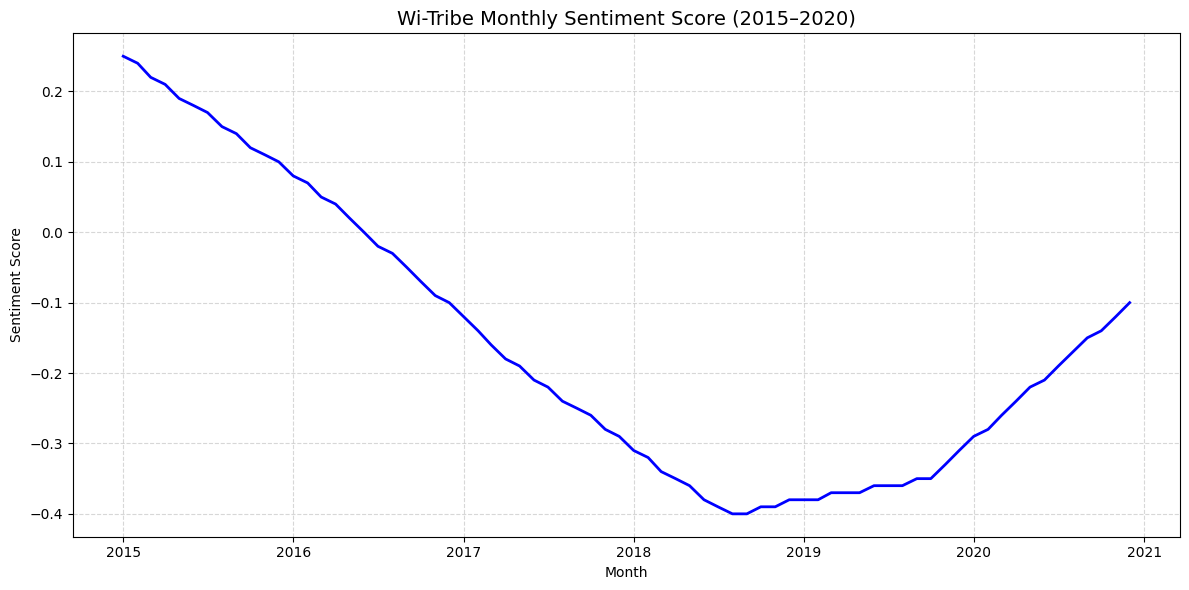

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV file
file_path = (r"C:\Users\IT SOLUTIONS\Downloads\WiTribe_Sentiment_Output_2015_2020.csv")
df = pd.read_csv(file_path)

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# ✅ 1. Line Chart – Sentiment Score Over Time
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Sentiment_Score'], color='blue', linewidth=2)
plt.title('Wi-Tribe Monthly Sentiment Score (2015–2020)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sentiment Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()








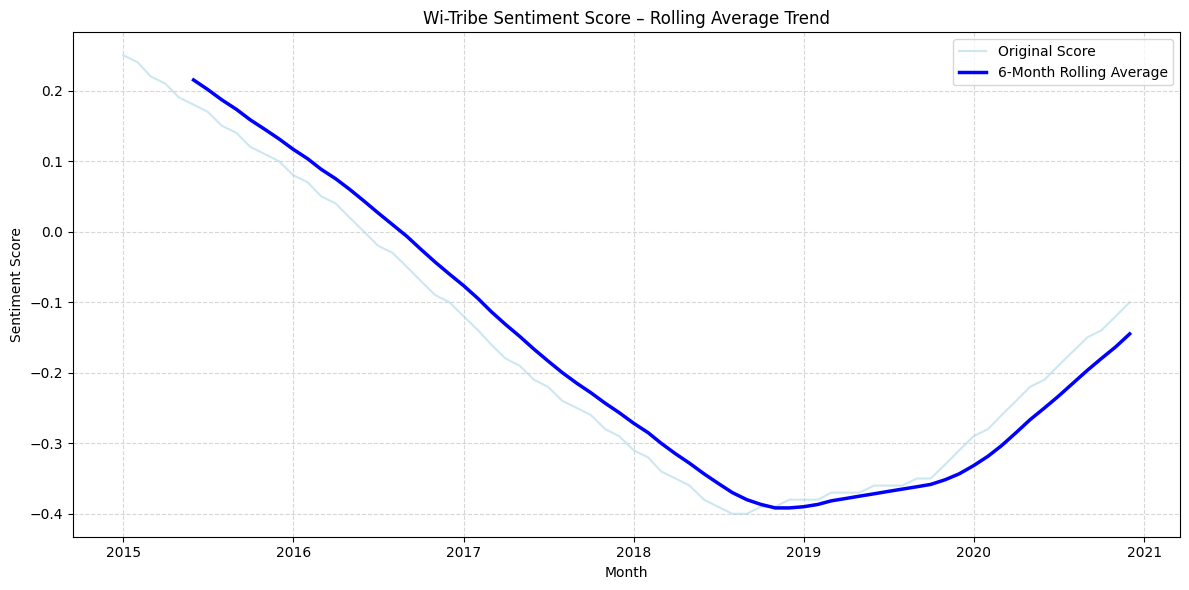

In [18]:
df['Rolling_Score'] = df['Sentiment_Score'].rolling(window=6).mean()  # 6-month moving average
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Sentiment_Score'], color='lightblue', alpha=0.6, label='Original Score')
plt.plot(df['Month'], df['Rolling_Score'], color='blue', linewidth=2.5, label='6-Month Rolling Average')
plt.title('Wi-Tribe Sentiment Score – Rolling Average Trend')
plt.xlabel('Month')
plt.ylabel('Sentiment Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


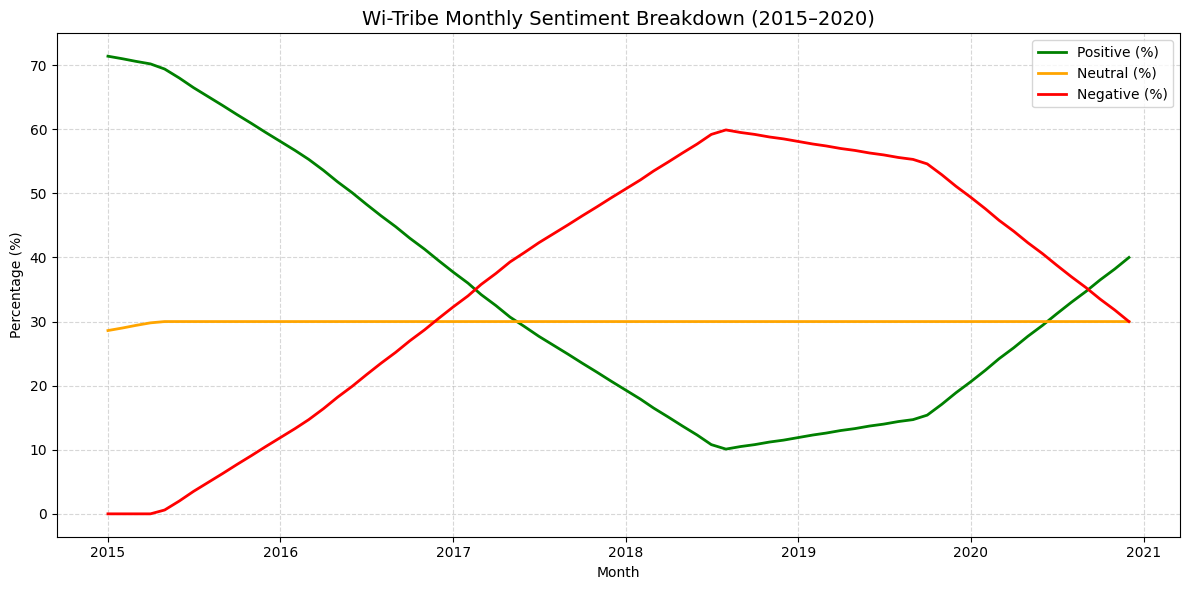

In [10]:
# ✅ 2. Multi-Line Chart – Positive, Neutral, Negative Trends
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Positive (%)'], color='green', label='Positive (%)', linewidth=2)
plt.plot(df['Month'], df['Neutral (%)'], color='orange', label='Neutral (%)', linewidth=2)
plt.plot(df['Month'], df['Negative (%)'], color='red', label='Negative (%)', linewidth=2)
plt.title('Wi-Tribe Monthly Sentiment Breakdown (2015–2020)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

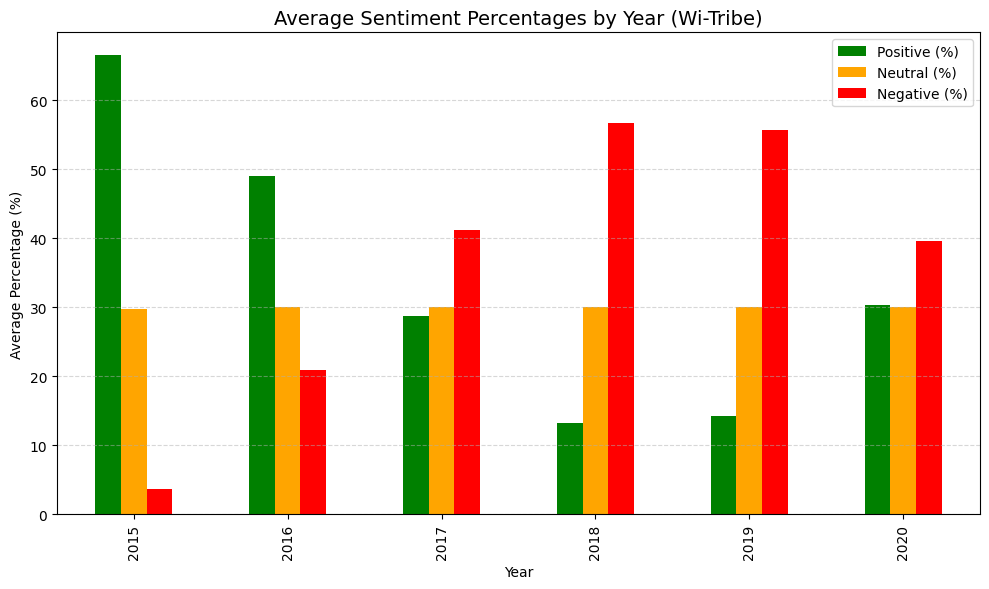

In [11]:
# ✅ 3. Average Sentiment Comparison by Year (Bar Graph)
df['Year'] = df['Month'].dt.year
yearly_avg = df.groupby('Year')[['Positive (%)', 'Neutral (%)', 'Negative (%)']].mean()

yearly_avg.plot(kind='bar', figsize=(10, 6), color=['green', 'orange', 'red'])
plt.title('Average Sentiment Percentages by Year (Wi-Tribe)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

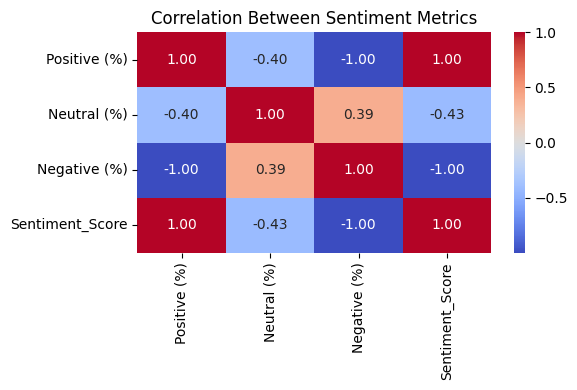

In [17]:
# ✅ 4. Correlation Heatmap (optional – requires seaborn)
try:
    import seaborn as sns
    plt.figure(figsize=(6, 4))
    sns.heatmap(df[['Positive (%)', 'Neutral (%)', 'Negative (%)', 'Sentiment_Score']].corr(),
                annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Between Sentiment Metrics')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install seaborn for the heatmap: pip install seaborn")

In [16]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import seaborn 